### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Dataset

In [2]:
df = pd.read_csv('../data/heart_2022_with_nans.csv')

display(df.head())
display(df.info())
display(df.isna().sum())

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


<class 'pandas.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  str    
 1   Sex                        445132 non-null  str    
 2   GeneralHealth              443934 non-null  str    
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  str    
 6   PhysicalActivities         444039 non-null  str    
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  str    
 9   HadHeartAttack             442067 non-null  str    
 10  HadAngina                  440727 non-null  str    
 11  HadStroke                  443575 non-null  str    
 12  HadAsthma                  443359 non-null  str    
 13  HadSkinCancer              441989 non-nu

None

State                            0
Sex                              0
GeneralHealth                 1198
PhysicalHealthDays           10927
MentalHealthDays              9067
LastCheckupTime               8308
PhysicalActivities            1093
SleepHours                    5453
RemovedTeeth                 11360
HadHeartAttack                3065
HadAngina                     4405
HadStroke                     1557
HadAsthma                     1773
HadSkinCancer                 3143
HadCOPD                       2219
HadDepressiveDisorder         2812
HadKidneyDisease              1926
HadArthritis                  2633
HadDiabetes                   1087
DeafOrHardOfHearing          20647
BlindOrVisionDifficulty      21564
DifficultyConcentrating      24240
DifficultyWalking            24012
DifficultyDressingBathing    23915
DifficultyErrands            25656
SmokerStatus                 35462
ECigaretteUsage              35660
ChestScan                    56046
RaceEthnicityCategor

In [3]:
display(df.describe())

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,434205.000000,436065.000000,439679.000000,416480.000000,403054.000000,396326.000000
mean,4.347919,4.382649,7.022983,1.702691,83.074470,28.529842
std,8.688912,8.387475,1.502425,0.107177,21.448173,6.554889
min,0.000000,0.000000,1.000000,0.910000,22.680000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.130000
50%,0.000000,0.000000,7.000000,1.700000,80.740000,27.440000
75%,3.000000,5.000000,8.000000,1.780000,95.250000,31.750000
max,30.000000,30.000000,24.000000,2.410000,292.570000,99.640000


In [4]:
df.drop_duplicates(inplace=True)

### Checking unique values

In [5]:
categorical_columns = df.select_dtypes(exclude='number').columns
for col in categorical_columns:
    print(f"{col}\n{df[col].unique()}\n")

State
<StringArray>
[             'Alabama',               'Alaska',              'Arizona',
             'Arkansas',           'California',             'Colorado',
          'Connecticut',             'Delaware', 'District of Columbia',
              'Florida',              'Georgia',               'Hawaii',
                'Idaho',             'Illinois',              'Indiana',
                 'Iowa',               'Kansas',             'Kentucky',
            'Louisiana',                'Maine',             'Maryland',
        'Massachusetts',             'Michigan',            'Minnesota',
          'Mississippi',             'Missouri',              'Montana',
             'Nebraska',               'Nevada',        'New Hampshire',
           'New Jersey',           'New Mexico',             'New York',
       'North Carolina',         'North Dakota',                 'Ohio',
             'Oklahoma',               'Oregon',         'Pennsylvania',
         'Rhode Island',       

### Trim whitespaces

In [6]:
categorical_cols = df.select_dtypes(exclude="number").columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

### Nan frequency and percentage

In [7]:
missing_data = pd.DataFrame({
    'NaN_Count': df.isna().sum(),
    'Percentage': (df.isna().sum() / len(df)) * 100
})
display(missing_data[missing_data['NaN_Count'] > 0].sort_values(by='Percentage', ascending=False))

,NaN_Count,Percentage
TetanusLast10Tdap,82370,18.511152
PneumoVaxEver,76894,17.280521
HIVTesting,65981,14.828024
ChestScan,55900,12.562504
CovidPos,50618,11.375471
HighRiskLastYear,50477,11.343783
BMI,48659,10.935221
FluVaxLast12,46975,10.556773
AlcoholDrinkers,46428,10.433845
WeightInKilograms,41931,9.423226


### Boxplot of numeric columns

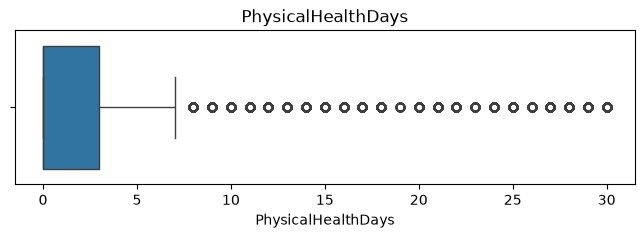

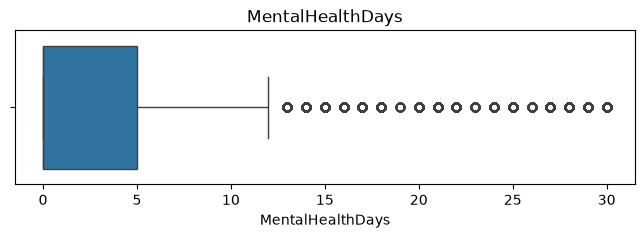

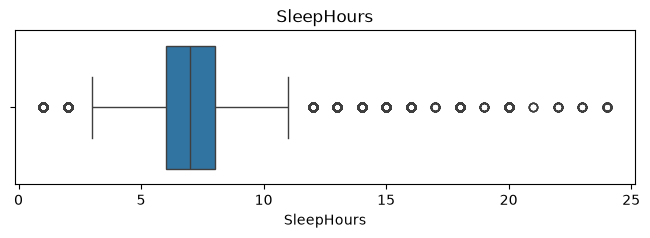

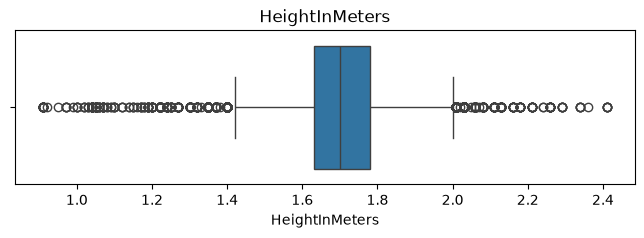

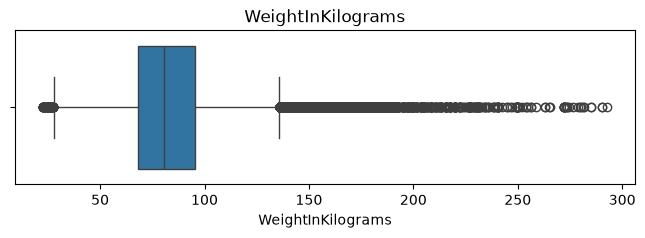

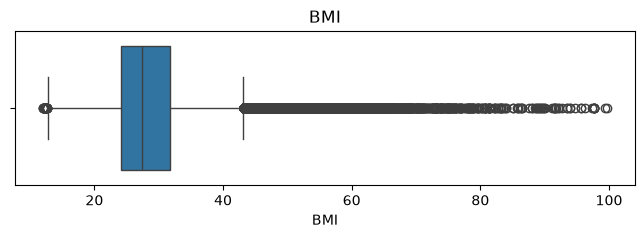

In [8]:
numeric_cols = df.select_dtypes(include="number").columns
for col in numeric_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Clipping the outliers for numeric columns

In [9]:
df['PhysicalHealthDays'] = df['PhysicalHealthDays'].clip(lower=0, upper=30)
df['MentalHealthDays'] = df['MentalHealthDays'].clip(lower=0, upper=30)
df['SleepHours'] = df['SleepHours'].clip(lower=4, upper=20)
df['HeightInMeters'] = df['HeightInMeters'].clip(lower=0.9, upper=2.5)
df['WeightInKilograms'] = df['WeightInKilograms'].clip(lower=30.0, upper=300.0)
df['BMI'] = df['BMI'].clip(lower=12.0, upper=100.0)

### Handling NaN of numeric columns

In [10]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    missing_pct = (df[col].isna().sum() / len(df)) * 100
    
    if 0 < missing_pct < 5:
        df = df.dropna(subset=[col])
    elif 5 <= missing_pct <= 30:
        df[col] = df[col].fillna(df[col].median())
    elif missing_pct > 30:
        df = df.drop(columns=[col])

### Handling Nan of numeric columns

In [11]:
categorical_cols = df.select_dtypes(exclude='number').columns

for col in categorical_cols:
    missing_pct = (df[col].isna().sum() / len(df)) * 100
    
    if 0 < missing_pct < 5:
        df = df.dropna(subset=[col])
    elif 5 <= missing_pct <= 30:
        df[col] = df[col].fillna(df[col].mode()[0])
    elif missing_pct > 30:
        df = df.drop(columns=[col])

### Visualizations

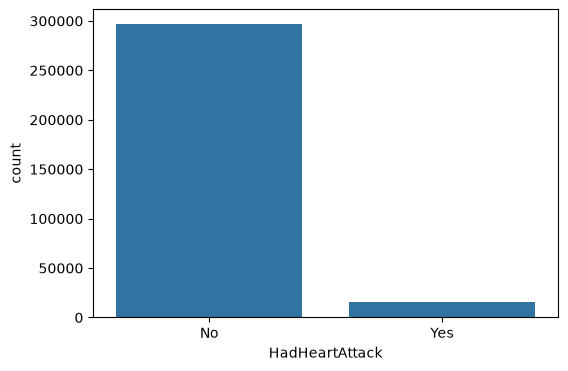

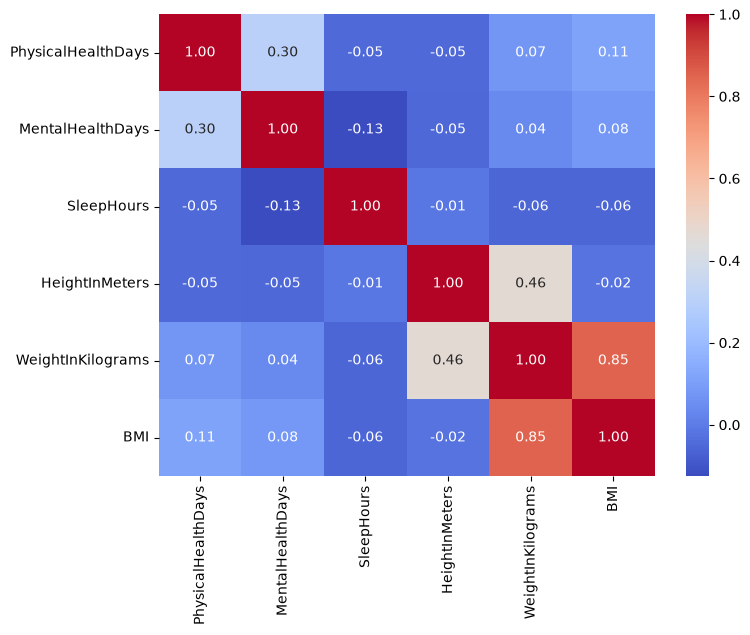

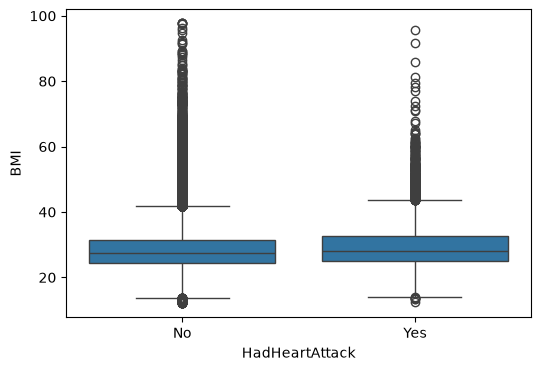

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='HadHeartAttack')
plt.show()

plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='HadHeartAttack', y='BMI')
plt.show()

### Exporting cleaned csv file

In [13]:
df = df.drop(columns=['WeightInKilograms', 'HeightInMeters']) 

df.to_csv('../data/heart_2022_cleaned_eda.csv', index=False)